### Task 3 (`penguins.csv`)

**Name:** Ali Afzal
**Roll No.:** SU92-BSAIM-F23-102
**Subject:** Data Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")

# House style copied from the Week 1 lecture: colour-blind-safe palette,
# left-aligned titles, no chart box, light grid.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "lines.linewidth": 2, "font.size": 11,
})


def note(ax, text, y=-0.2):
    # Grey footnote under a chart - used to say which rows were left out.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
df = pd.read_csv(DATA / "penguins.csv")
print(df.shape)
df.isna().sum()

(344, 7)


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [3]:
# Which penguins have gaps?
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


### Missing values - what I found and what I decided

There are 11 rows with gaps, and they fall into two groups:

- **2 penguins (rows 3 and 339) have no measurements at all.** Bill, flipper, mass and sex are all empty, so
  there is nothing to plot. I **drop them from every chart**.
- **9 penguins have every measurement but no sex recorded.** Their bills and weights are fine, so I keep them
  in charts 1-3, which don't use sex. I only drop them in chart 4, where sex is one of the groups.

I did not guess (impute) the missing sex, because a wrong guess would quietly change the male/female averages.
Each chart says in a footnote how many penguins it uses.

In [4]:
peng = df.dropna(subset=["body_mass_g"])     # 342 penguins with measurements
sexed = peng.dropna(subset=["sex"])          # 333 with known sex, only for chart 4
print(len(df), "->", len(peng), "->", len(sexed))

species = ["Adelie", "Chinstrap", "Gentoo"]
colours = dict(zip(species, [BLUE, ORANGE, AQUA]))   # colour = species, in every chart
bins = np.arange(2600, 6600, 200)                     # 200 g bins

344 -> 342 -> 333


### 1. Distribution of body mass

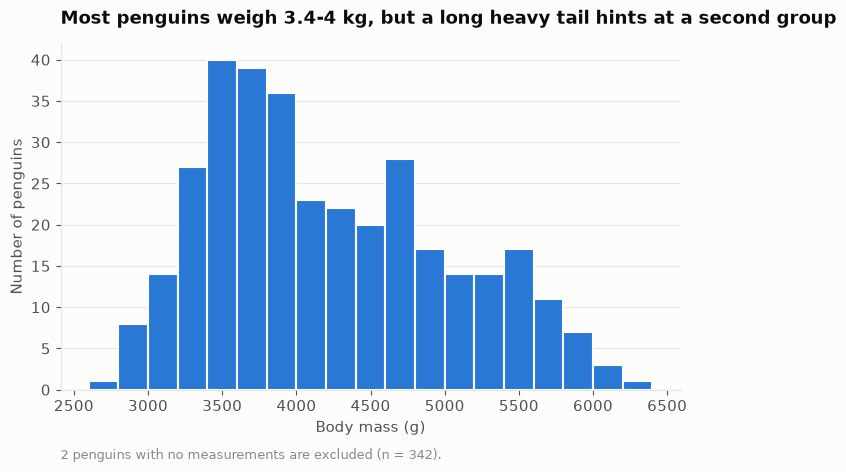

In [5]:
fig, ax = plt.subplots()
ax.hist(peng["body_mass_g"], bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=1.5)
ax.set_title("Most penguins weigh 3.4-4 kg, but a long heavy tail hints at a second group")
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")
ax.xaxis.grid(False)
note(ax, "2 penguins with no measurements are excluded (n = 342).")
plt.show()

**Why this chart:** body mass is one continuous number and the question is about its shape, so a histogram.
Penguin weights in the data are recorded to the nearest 25 g, so 200 g bins are wide enough to smooth out that
rounding but narrow enough to keep the shape visible.

**What shape is it?** It is not a single neat bell. There is one big hump around 3,400-4,000 g, then instead of
falling away smoothly the bars stay high all the way to about 5,600 g, with a small second bump near
4,600 g and another near 5,400 g. So the distribution is right-skewed, and it looks like more than one hump,
as if a second heavier group is mixed in. The mean (4,202 g) sits in a gap between the two, so it doesn't
describe a typical penguin very well.

### 2. The same distribution, split by species

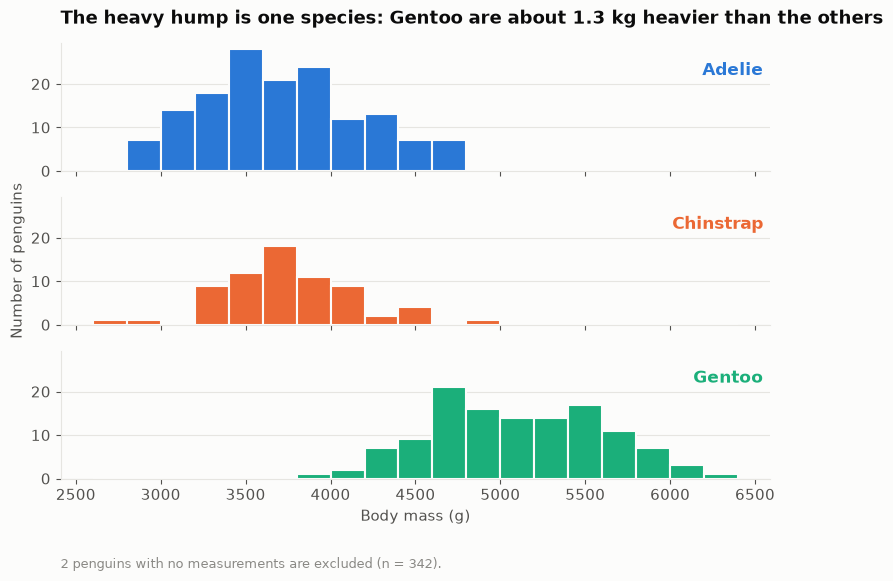

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True, sharey=True)
for ax, name in zip(axes, species):
    ax.hist(peng.loc[peng["species"] == name, "body_mass_g"], bins=bins,
            color=colours[name], edgecolor=SURFACE, linewidth=1.5)
    ax.text(0.99, 0.75, name, transform=ax.transAxes, ha="right", color=colours[name],
            fontsize=12, fontweight="bold")
    ax.xaxis.grid(False)

axes[0].set_title("The heavy hump is one species: Gentoo are about 1.3 kg heavier than the others")
axes[1].set_ylabel("Number of penguins")
axes[2].set_xlabel("Body mass (g)")
note(axes[2], "2 penguins with no measurements are excluded (n = 342).", y=-0.7)
fig.tight_layout()
plt.show()

**Why this chart:** the same histogram, but one panel per species. I used small multiples stacked on the same
x-axis instead of three overlapping histograms, because Adelie and Chinstrap overlap almost completely and one
would hide the other. Stacked like this, you can compare the position of each hump by just looking straight down.

**Does it explain step 1?** Yes, completely. Adelie and Chinstrap have almost the same distribution (both have a
median of 3,700 g), and together they make the big first hump. Gentoo is a separate, heavier group (median
5,000 g, and even the lightest Gentoo is 3,950 g), and it makes the long "tail". So the first chart was not one
skewed population. It was two groups mixed together. The small bumps inside each species are probably males
and females, which chart 4 looks at.

### 3. Bill length vs bill depth

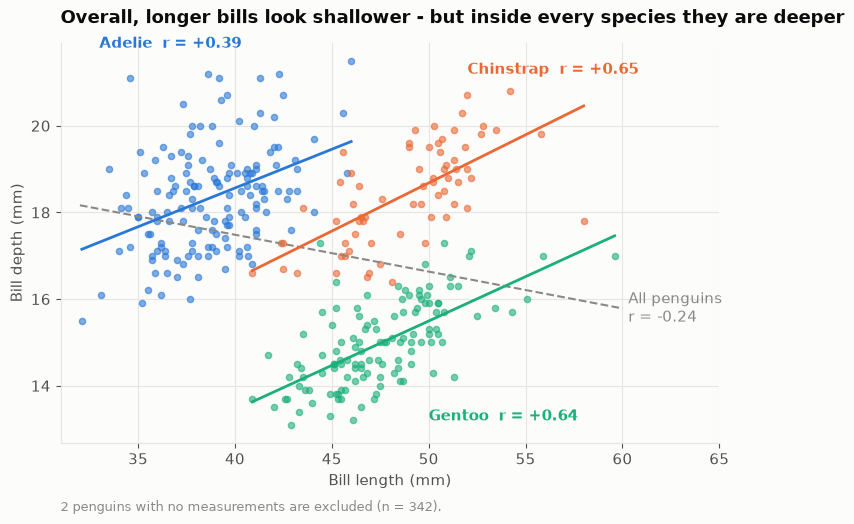

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Trend line across ALL penguins, ignoring species
slope, intercept = np.polyfit(peng["bill_length_mm"], peng["bill_depth_mm"], 1)
xs = np.array([32, 60])
ax.plot(xs, slope * xs + intercept, color=INK_MUTED, linestyle="--", linewidth=1.5)
r_all = peng["bill_length_mm"].corr(peng["bill_depth_mm"])
ax.text(60.3, slope * 60 + intercept, f"All penguins\nr = {r_all:.2f}", color=INK_MUTED, va="center")

# Each species on its own, with its own trend line
label_at = {"Adelie": (33, 21.8), "Chinstrap": (52, 21.2), "Gentoo": (50, 13.2)}
for name in species:
    g = peng[peng["species"] == name]
    ax.scatter(g["bill_length_mm"], g["bill_depth_mm"], s=20, color=colours[name], alpha=0.6)
    s, i = np.polyfit(g["bill_length_mm"], g["bill_depth_mm"], 1)
    x_range = np.array([g["bill_length_mm"].min(), g["bill_length_mm"].max()])
    ax.plot(x_range, s * x_range + i, color=colours[name])
    r = g["bill_length_mm"].corr(g["bill_depth_mm"])
    ax.text(*label_at[name], f"{name}  r = +{r:.2f}", color=colours[name], fontweight="bold")

ax.set_xlim(31, 65)
ax.set_title("Overall, longer bills look shallower - but inside every species they are deeper")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
note(ax, "2 penguins with no measurements are excluded (n = 342).", y=-0.17)
plt.show()

**Why this chart:** two numeric measurements and a question about whether they move together, so a scatter plot.
Colour carries real information here (species) and matches the colours in chart 2. I labelled each group on
the chart instead of using a legend, and added the trend lines because the whole point is the *direction* of
the relationship.

**What is going on?** If I ignore species (grey dashed line), the correlation is **-0.24**: penguins with longer
bills seem to have shallower bills. But inside each species the relationship is the other way round:
**+0.39** for Adelie, **+0.65** for Chinstrap and **+0.64** for Gentoo. Within a species, a bigger bill is
longer *and* deeper, which makes sense because bigger birds have bigger bills in every direction.

The overall negative trend comes from the differences *between* species. Adelie have short, deep bills (top left).
Gentoo have long, shallow bills (bottom right). When you throw everyone into one cloud, the line goes from
the Adelie group down to the Gentoo group, so it slopes down even though every species slopes up.

This is **Simpson's paradox**: a trend that appears in the combined data reverses when you split the data into
its groups. Species is the hidden (confounding) variable. If I had only computed one correlation for the whole
dataset, I would have reported the opposite of the truth. That is why the groups have to be plotted
separately.

### 4. Average body mass by species and sex

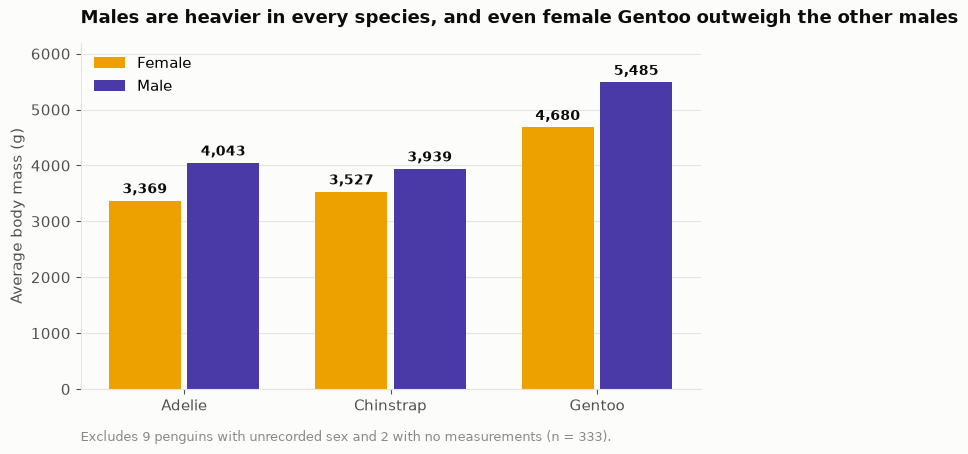

In [8]:
mass = sexed.groupby(["species", "sex"])["body_mass_g"].mean().unstack()
x = np.arange(len(mass))
width = 0.38

fig, ax = plt.subplots()
# Different colours from the species ones on purpose, so blue doesn't mean "Adelie" here.
for k, (sex, colour) in enumerate([("FEMALE", YELLOW), ("MALE", VIOLET)]):
    bars = ax.bar(x + (k - 0.5) * width, mass[sex], width=width * 0.92, color=colour, label=sex.title())
    ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=10, fontweight="bold", color=INK)

ax.set_xticks(x, mass.index)
ax.set_ylim(0, 6200)
ax.set_title("Males are heavier in every species, and even female Gentoo outweigh the other males")
ax.set_ylabel("Average body mass (g)")
ax.xaxis.grid(False)
ax.legend(loc="upper left")
note(ax, "Excludes 9 penguins with unrecorded sex and 2 with no measurements (n = 333).", y=-0.15)
plt.show()

**Why this chart:** there are two categories at once (species and sex) and I want to compare an average across
them, so a grouped bar chart, which the lecture called the ceiling for one chart. The bars start at zero because
the length of a bar is the value. I grouped by species so that female and male sit next to each other, since
the comparison I care about is *within* each species. Species stay in the same order as before (lightest to
heaviest), and each bar has its value written on it.

In every species the males are clearly heavier: about 670 g more for Adelie, 410 g for Chinstrap and 800 g for
Gentoo. The species gap is even bigger than the sex gap. A female Gentoo (4,680 g) outweighs a male Adelie
(4,043 g) or a male Chinstrap (3,939 g). This also explains the small bumps I saw inside each species in
chart 2.